FileChooser(path='G:\Mi unidad\Facultad\Beca CIN\NNMF-GIF\Señales AC3E\Femenino', filename='', title='', show_…

GridBox(children=(Dropdown(description='Norma:', layout=Layout(width='300px'), options=('frobenius', 'itakura-…

Button(button_style='success', description='Ejecutar', style=ButtonStyle())

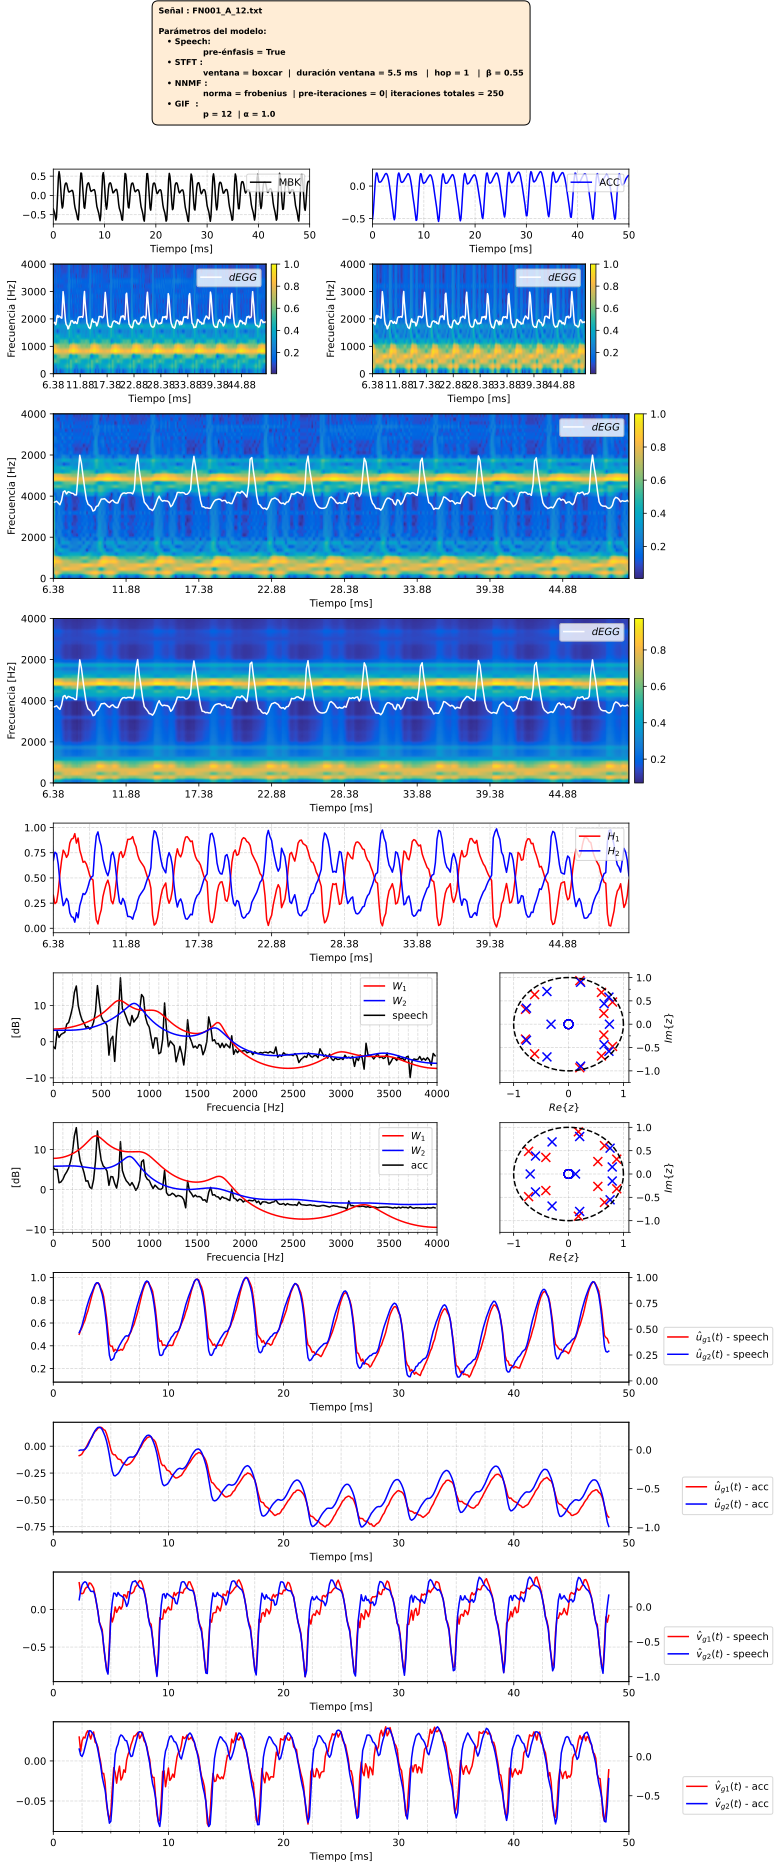

In [ ]:
# Interfaz
from ipyfilechooser import FileChooser
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
import numpy as np
import scipy.signal as sig
from NNMF_GIF2 import NNMF_GIF
import Funciones as Funciones
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'
from IPython.display import clear_output
# =========================================
cmap = Funciones.parula_map
color_ACC = 'blue'
color_EGG = 'orange'
color_dEGG = 'g'
color_OVV = 'magenta'
color_speech = 'black'
legend_loc = 'upper right'
color1 = 'red'
color2 = 'blue'
color3 = 'k'
line_width = 1.5
SP_ =  -1 
#==============================================================================================================================================================

fc = FileChooser('Señales AC3E/Femenino')
fc.layout = widgets.Layout(width='1000px')

norma = widgets.Dropdown(options = ['frobenius','itakura-saito'],
                         value = 'frobenius',
                         description = 'Norma:',
                         layout = widgets.Layout(width='300px'))

pre_iteraciones = widgets.BoundedIntText(value = 0,
                                         min = 0,
                                         max = 100,
                                         step = 1, 
                                         description = 'Pre-iteraciones:',
                                         style = {'description_width': 'initial'},
                                         layout = widgets.Layout(width='150px'))

iteraciones = widgets.BoundedIntText(value = 250,
                                     min = 10,
                                     max = 1000,
                                     step = 1,
                                     description = 'Iteraciones:',
                                     style  = {'description_width': 'initial'},
                                     layout = widgets.Layout(width='150px'))
p_filtro = widgets.BoundedIntText(value = 12,
                                  min = 6,
                                  max = 18,
                                  step = 1,
                                  description = 'p_filtro:',
                                  style = {'description_width': 'initial'},
                                  layout = widgets.Layout(width='150px'))
alfa = widgets.BoundedFloatText(value = 0.96,
                                min = 0.0,
                                max = 1.0,
                                step = 0.01,
                                description = 'α:',
                                style = {'description_width': 'initial'},
                                layout = widgets.Layout(width='150px'))
beta = widgets.BoundedFloatText(value = 0.55,
                             min = 0.1,
                             max = 2.0,
                             step = 0.05,
                             description = 'β:',
                             style = {'description_width': 'initial'},
                             layout =  widgets.Layout(width='150px'))
duracion_ventana = widgets.BoundedFloatText(value = 5.5,
                                    min = 1.0,
                                    max = 20.0,
                                    step = 0.5,
                                    description = 'Duración ventana (ms):',
                                    style = {'description_width': 'initial'},
                                    layout = widgets.Layout(width='300px'))
pre_enfasis               = widgets.Checkbox(value = True,
                                             description = 'Pre-énfasis')
guardar_proceso           = widgets.Checkbox(value = False,
                                             description = 'Guardar proceso')
normalizar_espectrogramas = widgets.Checkbox(value = True,
                                             description = 'Normalizar espectrogramas')
guardar = widgets.Checkbox(value = False,
                           description = 'Guardar')
boton   = widgets.Button(description = "Ejecutar",
                       button_style='success')

grid = widgets.GridBox(
    children=[norma,
              pre_iteraciones,
              iteraciones,
              p_filtro,
              alfa,
              beta,
              duracion_ventana,
              pre_enfasis,
              guardar_proceso,
              normalizar_espectrogramas,
              guardar],
    layout = widgets.Layout(grid_template_columns="repeat(4, auto)"))

#==============================================================================================================================================================

def ejecutar(b):

    clear_output(wait=True)
    display(fc, grid, boton)
    #==============================================================================================================================================================
    archivo = Path(fc.selected)
    nombre_archivo = archivo.name
    datos = np.loadtxt(archivo, delimiter='\t', skiprows=1)
    fs_r = 8000
    señal_MBK  = datos[:, 0]
    #b,a = sig.butter(4, 30, 'hp', fs=fs_r)
    #señal_MBK = sig.filtfilt(b,a,señal_MBK)
    señal_ACC  = -datos[:, 1]
    señal_EGG  = datos[:, 3]
    señal_dEGG = np.gradient(señal_EGG)
    if max(señal_dEGG) > 0:
        señal_dEGG = señal_dEGG / max(señal_dEGG) 
    to = 0
    tf = 50
    tiempos = np.arange(to, tf, 1000/fs_r)
    # ==============================================================================================================================================================
    SP = NNMF_GIF(speech=señal_MBK,
                  acelerometro=señal_ACC,
                  dEGG = señal_dEGG,
                  tiempos=tiempos,
                  fs=fs_r,
                  norma=norma.value,
                  pre_iteraciones=pre_iteraciones.value,
                  iteraciones=iteraciones.value,
                  p_filtro=p_filtro.value,
                  alfa=alfa.value,
                  beta=beta.value,
                  pre_enfasis=pre_enfasis.value,
                  duracion=duracion_ventana.value,
                  guardar_proceso=guardar_proceso.value,
                  normalizar_espectrogramas=normalizar_espectrogramas.value
    )
    SP_ = SP
    # ==============================================================================================================================================================
    fig = plt.figure(figsize=(8,30))
    widths  = [1,0.5,0.5,1]
    heights = [0.5,1,1.5,1.5,1,1,1,1,1,1,1]
    gs  = fig.add_gridspec(11, 4,width_ratios=widths,height_ratios=heights,left=0,right=1,wspace=0.65,hspace=0.35)

    # Señales temporales
    ax0 = fig.add_subplot(gs[0,0:2])
    ax1 = fig.add_subplot(gs[0,2:])
    # Espectrogramas
    ax2 = fig.add_subplot(gs[1,0:2])
    ax3 = fig.add_subplot(gs[1,2:])
    # Espectrograma
    ax4 = fig.add_subplot(gs[2,:])
    # Espectrograma aproximado
    ax5 = fig.add_subplot(gs[3,:])
    # Activacion
    ax6 = fig.add_subplot(gs[4,:])
    # Resp frecuencia y polos y ceros
    ax7 = fig.add_subplot(gs[5,:3])
    ax8 = fig.add_subplot(gs[5,3])
    # Resp frecuencia y polos y ceros
    ax9  = fig.add_subplot(gs[6,:3])
    ax10 = fig.add_subplot(gs[6,3])
    # Flujos
    ax11 = fig.add_subplot(gs[7,:])
    ax12 = fig.add_subplot(gs[8,:])
    # Funiones glóticas
    ax13 = fig.add_subplot(gs[9,:])
    ax14 = fig.add_subplot(gs[10,:])
    #=========================== Speech y ACC
    ax0.plot(tiempos,señal_MBK,color=color_speech,label='MBK')
    ax0.legend(loc=legend_loc)
    ax0.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
    ax0.set_xlabel('Tiempo [ms]') 
    ax0.set_xlim([0,50])
    # ------------- ACC
    ax1.plot(tiempos,señal_ACC,color=color_ACC,label='ACC')
    ax1.legend(loc=legend_loc)
    ax1.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
    ax1.set_xlabel('Tiempo [ms]') 
    ax1.set_xlim([0,50])
    #========================= Espectrograma speech
    im2 = ax2.imshow(SP.espectrograma_speech,
                    cmap=cmap,
                    origin='lower',
                    aspect='auto',
                    extent=[SP.to_espec, SP.tf_espec, SP.fo_espec, SP.ff_espec])
    ax2.set_ylabel('Frecuencia [Hz]')
    ax2.set_xlabel("Tiempo [ms]")
    fig.colorbar(im2, ax=ax2, pad=0.02)
     # ------------- dEGG
    ax2_ = ax2.twinx()
    ax2_.plot(SP.tiempos_espec,SP.dEGG,color='white', label=r"$dEGG$", linewidth=line_width)
    ax2_.legend(loc=legend_loc)
    ax2_.set_xlim(SP.to_espec, SP.tf_espec)
    ax2_.set_ylim([-2, 2])
    ax2_.set_xticks(np.arange(SP.to_espec, SP.tf_espec, SP.duracion_ventana))
    ax2_.set_yticks([])
    #========================= Espectrograma ACC
    im3 = ax3.imshow(SP.espectrograma_acc,
                     cmap = cmap,
                     origin='lower',
                     aspect='auto',
                     extent=[SP.to_espec,SP.tf_espec,SP.fo_espec,SP.ff_espec]);
    ax3.set_ylabel('Frecuencia [Hz]')
    fig.colorbar(im3, ax=ax3, pad=0.02)
    ax3_ = ax3.twinx()
     # ------------- dEGG
    ax3_.plot(SP.tiempos_espec,SP.dEGG,color='white',label=r"$dEGG$",linewidth=line_width);
    ax3_.legend(loc=legend_loc);
    ax3_.set_xlim(SP.to_espec,SP.tf_espec)
    ax3_.set_ylim([-2,2])
    ax3_.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana))
    ax3_.set_yticks([])
    ax3.set_xlabel('Tiempo [ms]')
    #========================= Espectrograma combinado
    im4 = ax4.imshow(SP.espectrograma_plot,
                     cmap = cmap,
                     origin='lower',
                     aspect='auto',
                     extent=[SP.to_espec,SP.tf_espec,SP.fo_espec,2*SP.ff_espec])
    yticks = [0, 2000, 4000, 6000, 8000]
    ax4.set_yticks(yticks)
    bbox = ax4.get_position()
    width = 0.015
    eps = 0.01
    # Nuevo eje para la barra de colores
    # [x0, y0, ancho, alto]
    cax = fig.add_axes([bbox.x1 + eps, bbox.y0, width, bbox.height])
    fig.colorbar(im4, cax=cax)
    ax4.set_yticklabels(['0', '2000', '4000', '2000', '4000'])
    ax4.set_ylabel('Frecuencia [Hz]')
     # ------------- dEGG   
    ax4_ = ax4.twinx()
    ax4_.plot(SP.tiempos_espec,SP.dEGG,color='white',label=r"$dEGG$",linewidth=line_width);
    ax4_.legend(loc='upper right')
    ax4_.set_xlim(SP.to_espec,SP.tf_espec)
    ax4_.set_ylim([-2,2])
    ax4_.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana))
    ax4_.set_yticks([])
    ax4.set_xlabel('Tiempo [ms]')
    #========================= Espectrograma aproximado

    im5 = ax5.imshow(SP.espectrograma_aprox_plot,
                     cmap = cmap,
                     origin='lower',
                     aspect='auto',
                     extent=[SP.to_espec,SP.tf_espec,SP.fo_espec,2*SP.ff_espec]);
    yticks = [0, 2000, 4000, 6000, 8000]
    ax5.set_yticks(yticks)
    bbox = ax5.get_position()
    width = 0.015
    eps = 0.01
    # Nuevo eje para la barra de colores
    # [x0, y0, ancho, alto]
    cax = fig.add_axes([bbox.x1 + eps, bbox.y0, width, bbox.height])
    fig.colorbar(im5, cax=cax)
    ax5.set_yticklabels(['0', '2000', '4000', '2000', '4000'])
    ax5.set_ylabel('Frecuencia [Hz]')
     # ------------- dEGG 
    ax5_ = ax5.twinx()
    ax5_.plot(SP.tiempos_espec,SP.dEGG,color='white',label=r"$dEGG$",linewidth=line_width);
    ax5_.legend(loc='upper right')
    ax5_.set_xlim(SP.to_espec,SP.tf_espec)
    ax5_.set_ylim([-2,2])
    ax5_.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana))
    ax5_.set_yticks([])
    ax5.set_xlabel('Tiempo [ms]')
    #========================= Funciones de activación
    ax6.plot(SP.tiempos_espec,SP.H1,color=color1,label=r'$H_1$')
    ax6.plot(SP.tiempos_espec,SP.H2,color=color2,label=r'$H_2$')
    ax6.set_xlim(SP.to_espec,SP.tf_espec)
    ax6.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana))
    ax6.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana/2),minor=True)
    ax6.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
    ax6.legend(loc=legend_loc)
    ax6.set_xlabel('Tiempo [ms]')
    #========================= Respuesta en frecuencia/polos-ceros speech
    # ------------- Respuesta en frecuencia
    theta = np.linspace(0, 2*np.pi, 200)
    fftseñal, fseñal = Funciones.FFT(señal_MBK, fs_r)
    fw1,hw1 = sig.freqz([1],SP.a_W1_speech,fs=fs_r)
    fw2,hw2 = sig.freqz([1],SP.a_W2_speech,fs=fs_r)
    ax7.plot(fw1, 10*np.log10(np.abs(hw1)), label=r'$W_1$', color=color1)
    ax7.plot(fw2, 10*np.log10(np.abs(hw2)), label=r'$W_2$', color=color2)
    ax7.plot(fseñal, 10*np.log10(np.abs(fftseñal)), label='speech', color=color3, zorder=-1)
    ax7.set_xlim(0,fs_r/2)
    ax7.set_xticks(np.arange(0, fs_r/2, 100), minor=True)
    ax7.grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
    ax7.set_xlabel('Frecuencia [Hz]')
    ax7.set_ylabel('[dB]')
    ax7.legend(loc='upper right')
     # ------------- Polos y ceros   
    ax8.plot(np.cos(theta), np.sin(theta), 'k--', alpha=1)
    ax8.yaxis.tick_right()
    ax8.yaxis.set_label_position("right")
    ax8.scatter(np.real(SP.ceros_W1_speech), np.imag(SP.ceros_W1_speech),s=80, facecolors='none', edgecolors=color1, label='Ceros')
    ax8.scatter(np.real(SP.polos_W1_speech), np.imag(SP.polos_W1_speech),s=80, marker='x', color=color1, label='Polos')
    ax8.scatter(np.real(SP.ceros_W2_speech), np.imag(SP.ceros_W2_speech),s=80, facecolors='none', edgecolors=color2, label='Ceros')
    ax8.scatter(np.real(SP.polos_W2_speech), np.imag(SP.polos_W2_speech),s=80, marker='x', color=color2, label='Polos')
    ax8.set_xticks(np.arange(-1.25,1.25,0.25), minor=True)
    ax8.set_yticks(np.arange(-1.25,1.25,0.25), minor=True)
    ax8.set_ylabel(r"$Im\{z\}$")
    ax8.set_xlabel(r"$Re\{z\}$")
    ax8.grid(True, linestyle='dashed', color='gray', alpha=0.3)
    #========================= Respuesta en frecuencia/polos-ceros ACC
    # ------------- Respuesta en frecuencia
    fftseñal, fseñal = Funciones.FFT(señal_ACC, fs_r)
    fw1,hw1 = sig.freqz([1],SP.a_W1_acc,fs=fs_r)
    fw2,hw2 = sig.freqz([1],SP.a_W2_acc,fs=fs_r)
    ax9.plot(fw1, 10*np.log10(np.abs(hw1)), label=r'$W_1$', color=color1)
    ax9.plot(fw2, 10*np.log10(np.abs(hw2)), label=r'$W_2$', color=color2)
    ax9.plot(fseñal, 10*np.log10(np.abs(fftseñal)), label='acc', color=color3, zorder=-1)
    ax9.set_xlim(0,fs_r/2)
    ax9.set_xticks(np.arange(0, fs_r/2, 100), minor=True)
    ax9.grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
    ax9.set_xlabel('Frecuencia [Hz]')
    ax9.set_ylabel('[dB]')
    ax9.legend(loc='upper right')
     # ------------- Polos y ceros   
    ax10.plot(np.cos(theta), np.sin(theta), 'k--', alpha=1)
    ax10.yaxis.tick_right()
    ax10.yaxis.set_label_position("right")
    ax10.scatter(np.real(SP.ceros_W1_acc), np.imag(SP.ceros_W1_acc),s=80, facecolors='none', edgecolors=color1, label='Ceros')
    ax10.scatter(np.real(SP.polos_W1_acc), np.imag(SP.polos_W1_acc),s=80, marker='x', color=color1, label='Polos')
    ax10.scatter(np.real(SP.ceros_W2_acc), np.imag(SP.ceros_W2_acc),s=80, facecolors='none', edgecolors=color2, label='Ceros')
    ax10.scatter(np.real(SP.polos_W2_acc), np.imag(SP.polos_W2_acc),s=80, marker='x', color=color2, label='Polos')
    ax10.set_xticks(np.arange(-1.25,1.25,0.25), minor=True)
    ax10.set_yticks(np.arange(-1.25,1.25,0.25), minor=True)
    ax10.set_ylabel(r"$Im\{z\}$")
    ax10.set_xlabel(r"$Re\{z\}$")
    ax10.grid(True, linestyle='dashed', color='gray', alpha=0.3)
    #========================= Flujos speech
    ax11.plot(SP.tiempos_gve,SP.flujo1_speech,color=color1,label=r'$\hat{u}_{g1}(t)$ - speech')
    ax11_ = ax11.twinx()
    ax11_.plot(SP.tiempos_gve,SP.flujo2_speech,color=color2,label=r'$\hat{u}_{g2}(t)$ - speech')
    ax11.set_xlim([to,tf])
    ax11.set_xticks(np.arange(to,tf,2.5),minor=True)
    ax11.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
    h1, l1 = ax11.get_legend_handles_labels()
    h2, l2 = ax11_.get_legend_handles_labels()
    ax11.legend(h1 + h2, l1 + l2, loc=legend_loc,bbox_to_anchor=(1.25, 0.5), borderaxespad=0.0)
    ax11.set_xlabel('Tiempo [ms]')
    #========================= Flujos ACC
    #b,a = sig.butter(4, 10, 'hp', fs=fs_r)
    #señal_MBK = sig.filtfilt(b,a,señal_MBK)
    ax12.plot(SP.tiempos_gve,SP.flujo1_acc,color=color1,label=r'$\hat{u}_{g1}(t)$ - acc')
    ax12_ = ax12.twinx()
    ax12_.plot(SP.tiempos_gve,SP.flujo2_acc,color=color2,label=r'$\hat{u}_{g2}(t)$ - acc')
    ax12.set_xlim([to,tf])
    ax12.set_xticks(np.arange(to,tf,2.5),minor=True)
    ax12.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
    h1, l1 = ax12.get_legend_handles_labels()
    h2, l2 = ax12_.get_legend_handles_labels()
    ax12.legend(h1 + h2, l1 + l2, loc=legend_loc,bbox_to_anchor=(1.25, 0.5), borderaxespad=0.0)
    ax12.set_xlabel('Tiempo [ms]')
    #========================= Funciones glóticas speech
    ax13.plot(SP.tiempos_gve,SP.dflujo1_speech,color=color1,label=r'$\hat{v}_{g1}(t)$ - speech')
    ax13_ = ax13.twinx()
    ax13_.plot(SP.tiempos_gve,SP.dflujo2_speech,color=color2,label=r'$\hat{v}_{g2}(t)$ - speech')
    ax13.set_xlim([to,tf])
    ax13.set_xticks(np.arange(to,tf,2.5),minor=True)
    ax13.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
    h1, l1 = ax13.get_legend_handles_labels()
    h2, l2 = ax13_.get_legend_handles_labels()
    ax13.legend(h1 + h2, l1 + l2, loc=legend_loc,bbox_to_anchor=(1.25, 0.5), borderaxespad=0.0)
    ax13.set_xlabel('Tiempo [ms]')
    #========================= Funciones glóticas ACC
    ax14.plot(SP.tiempos_gve,SP.dflujo1_acc,color=color1,label=r'$\hat{v}_{g1}(t)$ - acc');
    ax14_ = ax14.twinx()
    ax14_.plot(SP.tiempos_gve,SP.dflujo2_acc,color=color2,label=r'$\hat{v}_{g2}(t)$ - acc');
    ax14.set_xlim([to,tf])
    ax14.set_xticks(np.arange(to,tf,2.5),minor=True)
    ax14.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
    h1, l1 = ax14.get_legend_handles_labels()
    h2, l2 = ax14_.get_legend_handles_labels()
    ax14.legend(h1 + h2, l1 + l2, loc=legend_loc,bbox_to_anchor=(1.25, 0.5), borderaxespad=0.0)
    ax14.set_xlabel('Tiempo [ms]')
    fig.text(
    0.5, 0.955,  # centrado horizontalmente respecto a la figura
    f"Señal : {nombre_archivo}\n\n"
    f"Parámetros del modelo:\n"
    f"   • Speech:\n                pre-énfasis = {SP.pre_enfasis} \n"
    f"   • STFT : \n                ventana = {SP.ventana}  |  duración ventana = {SP.duracion_ventana:.1f} ms   |  hop = {SP.desplazamiento}   |  β = {SP.beta}\n"
    f"   • NNMF : \n                norma = {SP.norma}  | pre-iteraciones = {SP.n_pre_itereraciones}| iteraciones totales = {SP.n_iteraciones}  \n"
    f"   • GIF  : \n                p = {SP.orden_filtro_tracto}  | α = {SP.alfa}",
    ha='center', va='top',                 # centra el recuadro
    multialignment='left',                 # alinea el texto la izquierda
    fontsize=8, fontweight='bold',
    linespacing=1.4,
    bbox=dict(facecolor=(1, 0.925, 0.827, 0.949), edgecolor='black', boxstyle='round,pad=0.8')
    )
    if guardar.value:
        fig.savefig("Pruebas Repositorio AC3E/"+nombre_archivo+'.pdf',bbox_inches = 'tight')

boton.on_click(ejecutar)
display(fc, grid, boton)
